# Graph Neural Networks
Vamos implementar uma Graph Neural Network (GNN), especificamente uma GCN (Graph Convolutional Network). Vamos gerar um grafo de rede social artifical de forma que alguns perfis são fraudulentos e queremos prever isso com a GCN

In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import torch
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import ast
from sklearn.metrics import confusion_matrix

root = Path().resolve().parent.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Vamos utilizar do dataset [Cora](https://graphsandnetworks.com/the-cora-dataset/). Cora é uma rede de citações científicas com 2.708 artigos acadêmicos de machine learning como nós e 5.429 citações entre eles como arestas. Cada nó tem um vetor binário de 1.433 features representando a presença ou ausência de palavras de um vocabulário fixo no texto do artigo.

O objetivo é classificar cada artigo em uma das 7 áreas temáticas — Case Based, Genetic Algorithms, Neural Networks, Probabilistic Methods, Reinforcement Learning, Rule Learning e Theory — usando tanto as features do próprio artigo quanto a estrutura da rede de citações. A ideia central é que artigos que se citam tendem a ser da mesma área, então a topologia do grafo carrega sinal de classificação além do conteúdo textual.

In [2]:
# Seed fixa para reprodutibilidade
seed = 42
np.random.seed(seed)

Aqui nós baixamos os arquivos CSV dos nós e das arestas diretamente do site do cora e colocamos em uma pasta `data` na raíz do projeto. Fizemos um pequeno pré-processamento manual de colocar o nome da primeira coluna (coluna de index) como `index`. Ela, por padrão, vem sem nome

In [3]:
nodelist = pd.read_csv(root / 'data' / 'cora' / 'nodes.csv', sep=',', index_col="index")

In [4]:
nodelist.head()

,nodeId,labels,subject,features
index,,,,
0,31336,Paper,Neural_Networks,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1061127,Paper,Rule_Learning,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
2,1106406,Paper,Reinforcement_Learning,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,13195,Paper,Reinforcement_Learning,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,37879,Paper,Probabilistic_Methods,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [5]:
edgelist = pd.read_csv(root / 'data' / 'cora' / 'edges.csv', sep=',', index_col="index")

In [6]:
edgelist.head()

,sourceNodeId,targetNodeId,relationshipType
index,,,
0,35,1033,CITES
1,35,103482,CITES
2,35,103515,CITES
3,35,1050679,CITES
4,35,1103960,CITES


In [7]:
G = nx.Graph()

In [8]:
# Adiciona nós
for _, row in nodelist.iterrows():

    features = ast.literal_eval(row["features"])

    G.add_node(
        row["nodeId"],
        label=row["subject"],
        features=features
    )

# Adiciona arestas
for _, row in edgelist.iterrows():
    G.add_edge(
        row["sourceNodeId"],
        row["targetNodeId"],
        relationship=row["relationshipType"]
    )

Mostrando grafo gerado

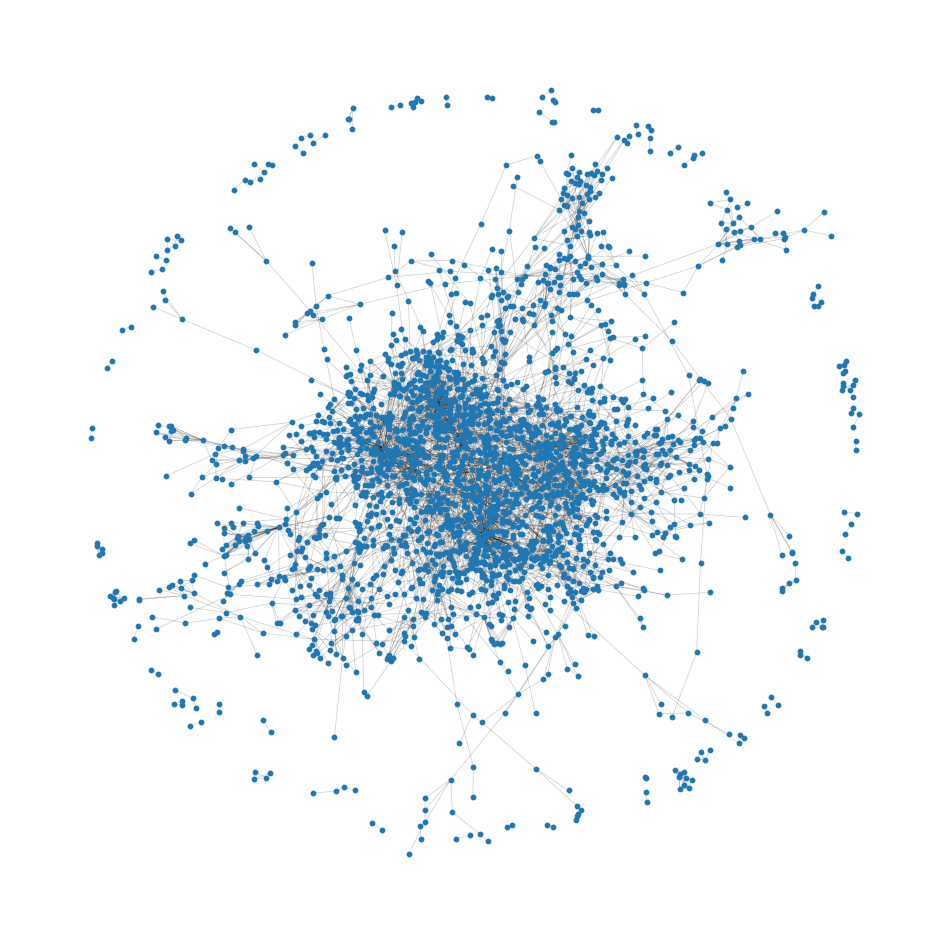

In [9]:
plt.figure(figsize=(12, 12))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=10
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2,
    width=0.5
)

plt.axis("off")
plt.show()

Montando a matriz de adjacência e a matriz de features

In [10]:
nodes = list(G.nodes())

# Montando a matriz de features
X = torch.tensor(
    [G.nodes[n]["features"] for n in nodes],
    dtype=torch.float32,
    device=device
)

# Montando a matriz de adjacência normalizada
A = torch.tensor(   # Adjacência padrão
    nx.to_numpy_array(G, nodelist=nodes),
    dtype=torch.float32,
    device=device
)

A_hat = A + torch.eye(A.shape[0], device=device)  # Adicionando self-loops

# Montando a matriz de graus
degree = A_hat.sum(dim=1)
degree[degree == 0] = 1

D_inv_sqrt = torch.diag(torch.pow(degree, -0.5))

# Matriz de adjacência normalizada
A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt

No entanto, GCNs não seguem o padrão de dividir os dados em treino e teste e ficarem independentes, na verdade a rede tem acesso à TODO o grafo, no entanto, na hora de gerar os outputs, apenas os nós classificados para treino são usados e contribuem para o gradiente da loss, então vamos gerar duas máscaras, uma para **treino** e outra para **teste**

In [11]:
# Criando as máscaras de treino e de teste (80%/20%)
num_nodes = X.shape[0]

perm = torch.randperm(num_nodes)

train_size = int(0.8 * num_nodes)

train_idx = perm[:train_size]
test_idx = perm[train_size:]

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

print(f"Nós de treino: {train_mask.sum()}")
print(f"Nós de teste: {test_mask.sum()}")

Nós de treino: 2166
Nós de teste: 542


Também temos que ajustar o vetor de TARGET para que possa ficar no formato ONE-HOT, temos que converter de um vetor de labels para uma matriz onde cada coluna representa uma classe

In [12]:
labels = nodelist["subject"].unique().tolist()
# Montando o dataframe que será utilizado para representar a matriz
target_df = pd.DataFrame([], columns=labels)

for n in nodes:
    node = G.nodes[n]  # Pego o nó atual
    target_vec = np.zeros((len(labels),))  # Monto um vetor target de 0
    idx = labels.index(node["label"])  # Pego o índice do label desse nó
    target_vec[idx] = 1
    target_df.loc[len(target_df)] = target_vec


t_one_hot = torch.tensor(
    target_df.to_numpy(),
    dtype=torch.float32,
    device=device
)

In [13]:
from layers import GCNLayer
from losses import CrossEntropyLogit
from optimizers import SGD
from functions import ReLU
from core import Sequential

mlp = Sequential(
    GCNLayer(X.shape[1], 64, A_norm),
    ReLU(),

    GCNLayer(64, 7, A_norm)
).to(device)

criterium = CrossEntropyLogit()

optimizer = SGD(mlp.parameters(), learning_rate=0.05)

In [14]:
loss_hist: list[float] = []

for epoch in range(1000):
    optimizer.zero_grad()  # Reseta gradientes

    # Forward pass (predição de logits, shape N x 2)
    y = mlp.forward(X)

    # Calculamos a perda comparando as predições com os alvos em formato One-Hot
    loss = criterium.forward(y[train_mask], t_one_hot[train_mask])

    loss_hist.append(loss.item())

    # Backward pass
    dloss = criterium.backward()

    full_dloss = torch.zeros(
        train_mask.shape[0],
        dloss.shape[1],
        device=dloss.device,
        dtype=dloss.dtype,
    )

    full_dloss[train_mask] = dloss

    mlp.backward(full_dloss)

    # Atualização de parâmetros
    optimizer.step()

Após o treinamento da rede, vamos verificar como ela desempenha mostrando o histórico da perca, a acurácia do modelo e a matriz de confusão

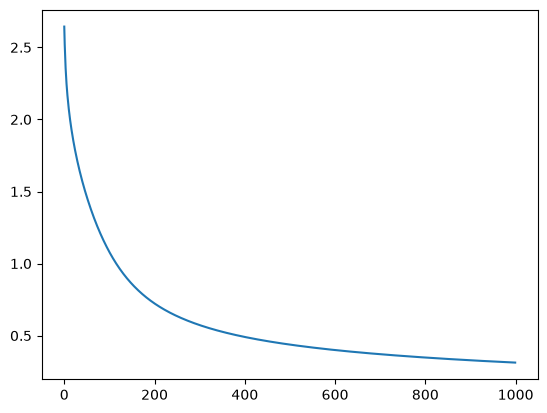

In [15]:
plt.plot(list(range(len(loss_hist))), loss_hist)
plt.show()

In [16]:
# 1. Coloca o modelo em modo de avaliação (desativa gradientes e dropouts se houver)
# mlp.eval()

# 2. Executa o forward no conjunto de teste
logits_test = mlp.forward(X)

# 3. Obtém o índice da classe com maior pontuação (predição final 0 ou 1)
y_one_hot = torch.nn.functional.one_hot(
    logits_test.argmax(dim=1),
    num_classes=7
).float()

# 4. Compara com os rótulos de teste reais (t_test_tensor) e extrai as métrics
pred = y_one_hot[test_mask]
target = t_one_hot[test_mask]

pred_classes = y_one_hot[test_mask].argmax(dim=1)
true_classes = t_one_hot[test_mask].argmax(dim=1)

accuracy = (pred_classes == true_classes).float().mean()
print(f"Accuracy: {accuracy.item():.4f}")

Accuracy: 0.8911


In [17]:
from sklearn.metrics import classification_report

print(
    classification_report(
        target.cpu(),
        pred.cpu(),
        labels=list(range(7)),
        target_names=labels,
        zero_division=0
    )
)

                        precision    recall  f1-score   support

       Neural_Networks       0.94      0.93      0.93       162
         Rule_Learning       0.83      0.81      0.82        42
Reinforcement_Learning       0.89      0.80      0.85        41
 Probabilistic_Methods       0.90      0.83      0.86        83
                Theory       0.77      0.85      0.81        73
    Genetic_Algorithms       0.97      0.98      0.97        86
            Case_Based       0.85      0.93      0.89        55

             micro avg       0.89      0.89      0.89       542
             macro avg       0.88      0.87      0.88       542
          weighted avg       0.89      0.89      0.89       542
           samples avg       0.89      0.89      0.89       542

